# Name: Musfira (280048443)
# Name: Amzi (281133626)

# COMP360 Lab: Regression with Linear Regression

**Student notebook template**

In this lab, we predict a continuous value: exam score from study hours.

## 1. Import libraries and load dataset

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
import pandas as pd

data = {
    'Hours_Studied': [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
                      6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5],
    'Exam_Score': [35, 38, 45, 48, 52, 56, 60, 63, 68, 70,
                   74, 78, 81, 84, 88, 90, 92, 94, 96, 98]
}

df = pd.DataFrame(data)
df.head()

,Hours_Studied,Exam_Score
0,1.0,35
1,1.5,38
2,2.0,45
3,2.5,48
4,3.0,52


**Question 1:** What is the feature column? What is the target column?

**Answer:**

Feature column: Hours_Studied

Target column: Exam_Score


## 2. Visualize the relationship

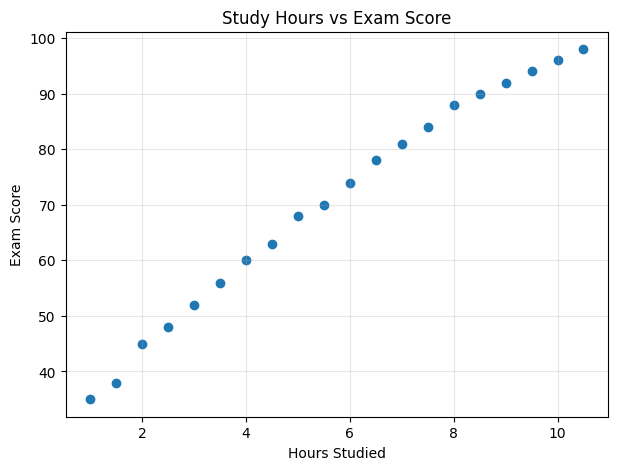

In [20]:
# Create a scatter plot of Hours_Studied vs Exam_Score
plt.figure(figsize=(7, 5))

plt.scatter(df['Hours_Studied'], df['Exam_Score'])

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.grid(True, alpha=0.3)

plt.show()

**Question 2:** Does the relationship look positive, negative, or unclear?

**Answer:**

The relationship looks positive because exam scores increase as study hours increase.

## 3. Train/test split

In [21]:
X = df[['Hours_Studied']]
y = df['Exam_Score']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training examples:', len(X_train))
print('Testing examples:', len(X_test))

Training examples: 16
Testing examples: 4


**Question 3:** Why do we evaluate on test data?

**Answer:**

We evaluate on test data to check whether the model can make accurate predictions on unseen examples instead of only memorizing the training data.

## 4. Train Linear Regression

In [22]:
# Create and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print('Slope:', round(slope, 3))
print('Intercept:', round(intercept, 3))

Slope: 6.463
Intercept: 33.892


**Question 4:** Interpret the slope in plain English.

**Answer:**

The slope shows how much the predicted exam score increases for every additional hour studied.

## 5. Predict and evaluate

In [23]:
# Predict scores for the test set
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Hours_Studied': X_test['Hours_Studied'].values,
    'Actual_Score': y_test.values,
    'Predicted_Score': np.round(y_pred, 2),
    'Error': np.round(y_test.values - y_pred, 2)
})

results

,Hours_Studied,Actual_Score,Predicted_Score,Error
0,1.0,35,40.35,-5.35
1,9.5,94,95.29,-1.29
2,8.5,90,88.83,1.17
3,1.5,38,43.59,-5.59


In [24]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print('MAE:', round(mae, 3))
print('MSE:', round(mse, 3))
print('RMSE:', round(rmse, 3))
print('R-squared:', round(r2, 3))

MAE: 3.351
MSE: 15.73
RMSE: 3.966
R-squared: 0.98


**Question 5:** Which metric is easiest for a non-technical person to understand? Why?

**Answer:**

MAE is easiest to understand because it shows the average prediction error in actual exam score points.


## 6. Plot regression line

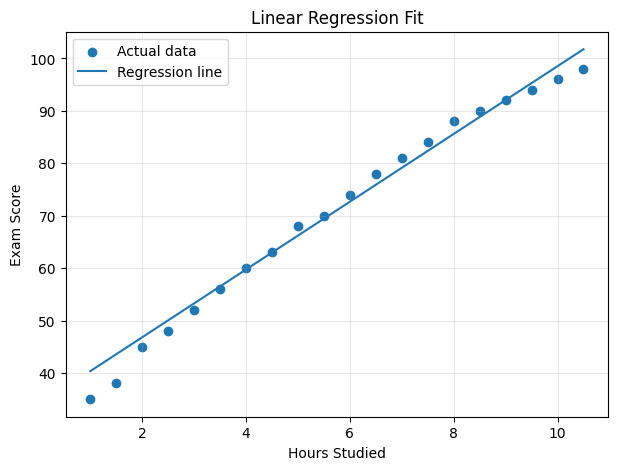

In [25]:
# Plot data points and the learned regression line
plt.figure(figsize=(7, 5))

plt.scatter(df['Hours_Studied'], df['Exam_Score'], label='Actual data')

x_line = np.linspace(
    df['Hours_Studied'].min(),
    df['Hours_Studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(
    pd.DataFrame(x_line, columns=['Hours_Studied'])
)

plt.plot(x_line, y_line, label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression Fit')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 7. Predict a new case

In [26]:
# Predict score for a student who studied 6.5 hours
new_hours = pd.DataFrame({'Hours_Studied': [6.5]})

predicted_score = model.predict(new_hours)[0]

print('Predicted score:', round(predicted_score, 2))

Predicted score: 75.9


**Question 6:** Why should this prediction not be treated as guaranteed?

**Answer:**

This prediction is not guaranteed because exam performance also depends on factors like stress, sleep, and preparation.


## 8. Optional extension: underfitting and overfitting intuition

Run this only if time permits. It compares simple polynomial curves.

In [27]:
# Optional: compare polynomial models of different degrees
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

for degree in [1, 3, 10]:
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(X_train, y_train)
    train_score = poly_model.score(X_train, y_train)
    test_score = poly_model.score(X_test, y_test)
    print(f'Degree {degree}: Train R2={train_score:.3f}, Test R2={test_score:.3f}')

Degree 1: Train R2=0.988, Test R2=0.980
Degree 3: Train R2=0.999, Test R2=0.994
Degree 10: Train R2=1.000, Test R2=0.893


## Final Reflection

Write 4-6 lines explaining what you learned about prediction, error, and responsible interpretation.

This lab showed us how Linear Regression can predict continuous values and measure error. We also learned that studying more usually leads to higher exam scores, but real predictions are never exact.


# AI tools

AI tools were used only for explanation, and all work was reviewed, debugged, and understood by the group members.
